In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

from scipy.cluster.hierarchy import dendrogram, linkage

In [27]:
iris = load_iris()
X = iris.data
y = iris.target

In [28]:
df = pd.DataFrame(X, columns = iris.feature_names)
print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


In [29]:
X_train, X_test = train_test_split(X, test_size = 0.3, random_state=42)

In [42]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

agg = AgglomerativeClustering(n_clusters = 3, linkage = 'ward')
cluster_labels = agg.fit_predict(X_scaled)

df_train = pd.DataFrame(X_train, columns = iris.feature_names)
df_train['Cluster'] = cluster_labels
print(df_train)

sil_score = silhouette_score(X_scaled, cluster_labels)
print("\nSilhouette Score : ", sil_score)

     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                  5.5               2.4                3.7               1.0   
1                  6.3               2.8                5.1               1.5   
2                  6.4               3.1                5.5               1.8   
3                  6.6               3.0                4.4               1.4   
4                  7.2               3.6                6.1               2.5   
..                 ...               ...                ...               ...   
100                6.1               2.8                4.0               1.3   
101                4.9               2.5                4.5               1.7   
102                5.8               4.0                1.2               0.2   
103                5.8               2.6                4.0               1.2   
104                7.1               3.0                5.9               2.1   

     Cluster  
0          0

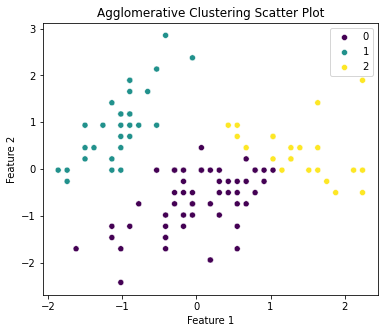

In [43]:
plt.figure(figsize = (6,5))
sns.scatterplot(x=X_scaled[:,0],y= X_scaled[:,1], hue=cluster_labels, palette = 'viridis')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title("Agglomerative Clustering Scatter Plot")
plt.show()

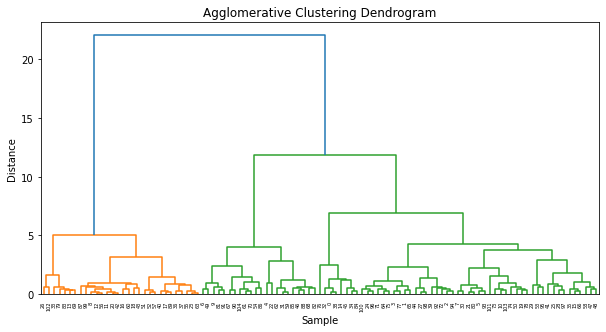

In [44]:
plt.figure(figsize = (10,5))
linked = linkage(X_scaled, method = 'ward')
dendrogram(linked)
plt.xlabel('Sample')
plt.ylabel('Distance')
plt.title("Agglomerative Clustering Dendrogram")
plt.show() 

In [45]:
new_sample = [[5.1,3.5,1.4,0.2]]
new_sample_scaled = scaler.transform(new_sample)

predicted_clusters = AgglomerativeClustering(new_sample_scaled)
print("New Sample Class: ", predicted_clusters)

New Sample Class:  AgglomerativeClustering(n_clusters=array([[-0.89573553,  1.17645543, -1.44207638, -1.40568508]]))
